In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

In [2]:
df = pd.read_csv("/content/Books_store.csv")

In [3]:
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1070 entries, 0 to 1069
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   index                1070 non-null   int64  
 1   Publishing Year      1069 non-null   float64
 2   Book Name            1047 non-null   object 
 3   Author               1070 non-null   object 
 4   language_code        1017 non-null   object 
 5   Author_Rating        1070 non-null   object 
 6   Book_average_rating  1070 non-null   float64
 7   Book_ratings_count   1070 non-null   int64  
 8   genre                1070 non-null   object 
 9   gross sales          1070 non-null   float64
 10  publisher revenue    1070 non-null   float64
 11  sale price           1070 non-null   float64
 12  sales rank           1070 non-null   int64  
 13  Publisher            1070 non-null   object 
 14  units sold           1070 non-null   int64  
dtypes: float64(5), int64(4), object(6)
mem

In [5]:
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1070.000000,1069.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,534.500000,1971.377923,4.007000,94909.913084,1856.622944,843.281030,4.869561,611.652336,9676.980374
std,309.026698,185.080257,0.247244,31513.242518,3936.924240,2257.596743,3.559919,369.849830,15370.571306
min,0.000000,-560.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,267.250000,1985.000000,3.850000,70398.000000,372.465000,0.000000,1.990000,287.500000,551.250000
50%,534.500000,2003.000000,4.015000,89309.000000,809.745000,273.078000,3.990000,595.500000,3924.000000
75%,801.750000,2010.000000,4.170000,113906.500000,1487.957500,721.180500,6.990000,932.500000,5312.250000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


In [6]:
df.isnull().sum()

,0
index,0
Publishing Year,1
Book Name,23
Author,0
language_code,53
Author_Rating,0
Book_average_rating,0
Book_ratings_count,0
genre,0
gross sales,0


In [7]:
df = df.dropna()

In [8]:
median_sales = df["units sold"].median()

df["Sales_Status"] = np.where(
    df["units sold"] >= median_sales,
    "High",
    "Low"
)

In [9]:
df[["units sold","Sales_Status"]].head()

,units sold,Sales_Status
0,7000,High
1,6250,High
2,5500,High
3,5500,High
4,4750,High


In [13]:
# Standardize column names to avoid case and spacing issues
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

le = LabelEncoder()

df["genre"] = le.fit_transform(df["genre"])
df["author"] = le.fit_transform(df["author"])
df["publisher"] = le.fit_transform(df["publisher"])
df["language_code"] = le.fit_transform(df["language_code"])
df["book_name"] = le.fit_transform(df["book_name"])

df["sales_status"] = le.fit_transform(df["sales_status"])

In [15]:
X = df[[
    "publishing_year",
    "genre",
    "author_rating",
    "book_average_rating",
    "book_ratings_count",
    "gross_sales",
    "publisher_revenue",
    "sale_price",
    "sales_rank"
]]

y = df["sales_status"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
dt = DecisionTreeClassifier(random_state=42)

# Apply Label Encoding to 'author_rating' in X_train and X_test
# Since X_train and X_test are already split, we fit on X_train and transform both.
le_author_rating = LabelEncoder()
X_train['author_rating'] = le_author_rating.fit_transform(X_train['author_rating'])
X_test['author_rating'] = le_author_rating.transform(X_test['author_rating'])

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.985


In [19]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.975


In [20]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.695


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
svm = SVC(probability=True, random_state=42)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.72


In [22]:
accuracy = pd.DataFrame({
    "Algorithm":[
        "Decision Tree",
        "Random Forest",
        "Logistic Regression",
        "SVM"
    ],
    "Accuracy":[
        dt_acc,
        rf_acc,
        lr_acc,
        svm_acc
    ]
})

print(accuracy)

             Algorithm  Accuracy
0        Decision Tree     0.985
1        Random Forest     0.975
2  Logistic Regression     0.695
3                  SVM     0.720


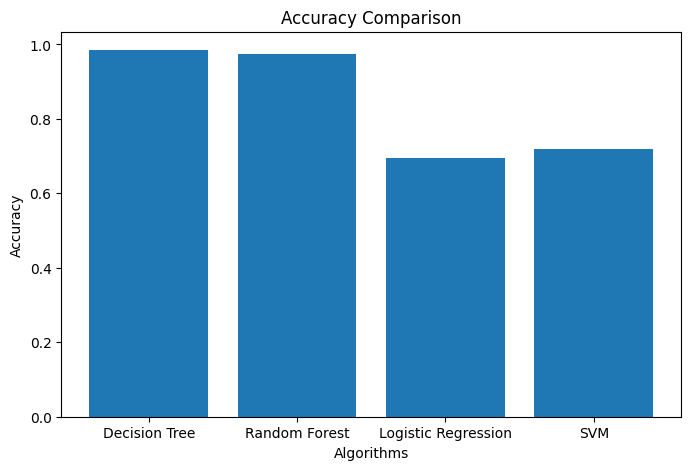

In [23]:
plt.figure(figsize=(8,5))

plt.bar(
    accuracy["Algorithm"],
    accuracy["Accuracy"]
)

plt.title("Accuracy Comparison")

plt.xlabel("Algorithms")

plt.ylabel("Accuracy")

plt.show()

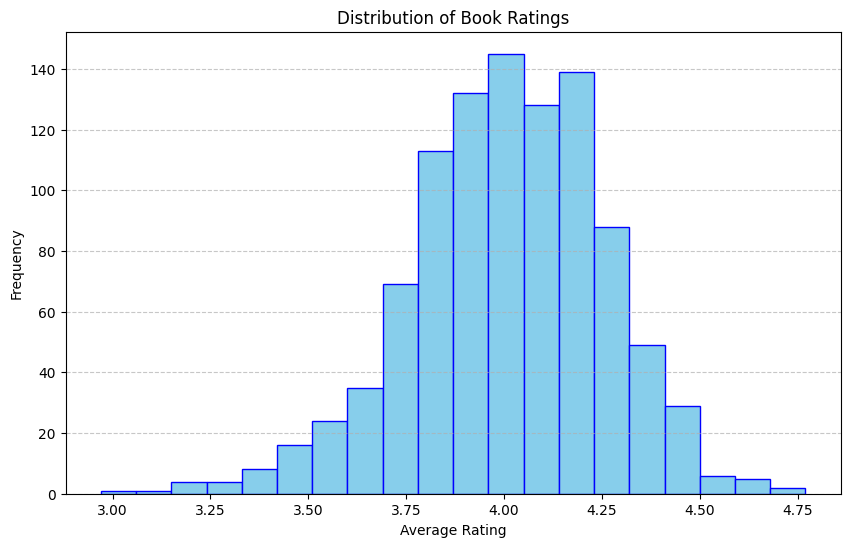

In [25]:
plt.figure(figsize=(10, 6))
plt.hist(df['book_average_rating'], bins=20, color='skyblue', edgecolor='blue')
plt.title('Distribution of Book Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

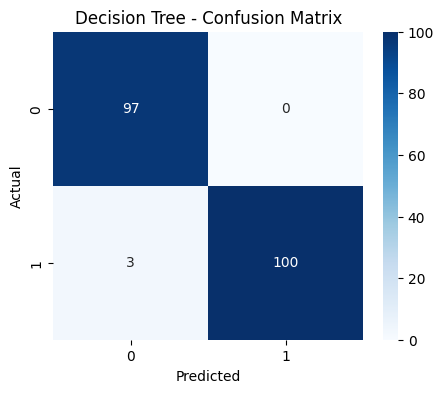

In [26]:
cm_dt = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

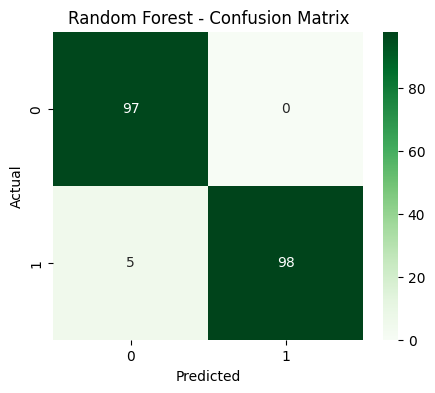

In [27]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

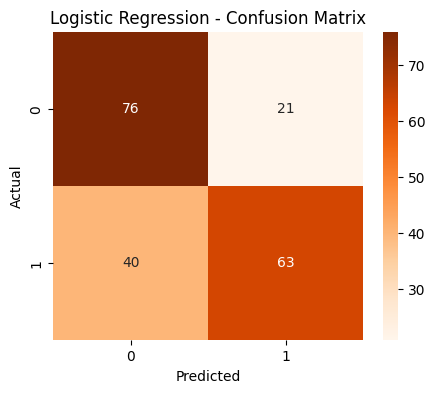

In [28]:
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges')

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

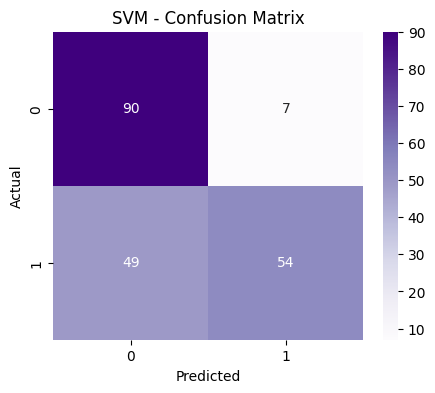

In [29]:
cm_svm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples')

plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [30]:
print("Decision Tree")
print(classification_report(y_test, dt_pred))

print("Random Forest")
print(classification_report(y_test, rf_pred))

print("Logistic Regression")
print(classification_report(y_test, lr_pred))

print("SVM")
print(classification_report(y_test, svm_pred))

Decision Tree
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        97
           1       1.00      0.97      0.99       103

    accuracy                           0.98       200
   macro avg       0.98      0.99      0.98       200
weighted avg       0.99      0.98      0.99       200

Random Forest
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        97
           1       1.00      0.95      0.98       103

    accuracy                           0.97       200
   macro avg       0.98      0.98      0.97       200
weighted avg       0.98      0.97      0.98       200

Logistic Regression
              precision    recall  f1-score   support

           0       0.66      0.78      0.71        97
           1       0.75      0.61      0.67       103

    accuracy                           0.69       200
   macro avg       0.70      0.70      0.69       200
weighted avg       0.70   

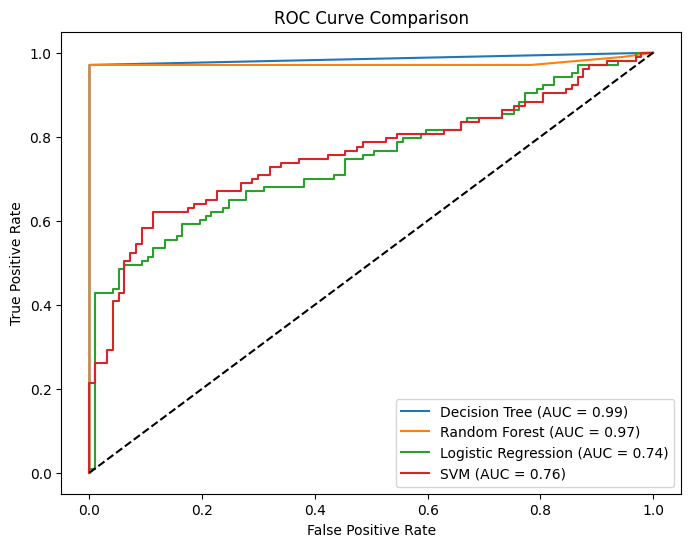

In [31]:
models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "Logistic Regression": lr,
    "SVM": svm
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

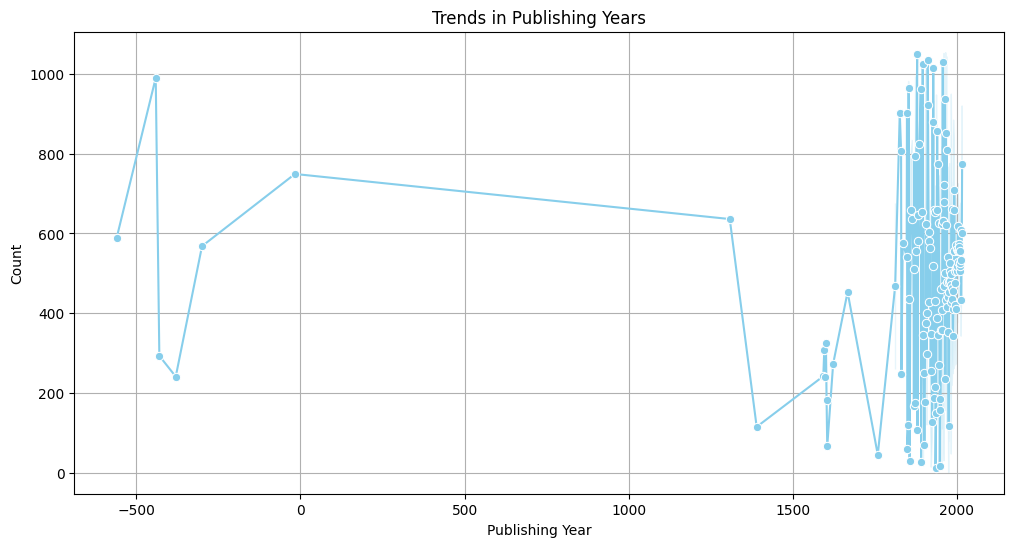

In [35]:
books_data_sorted = df.sort_values(by='publishing_year')

# Plotting the distribution of publishing years
plt.figure(figsize=(12, 6))
sns.lineplot(x=books_data_sorted['publishing_year'], y=books_data_sorted.index, marker='o', color='skyblue')
plt.title('Trends in Publishing Years')
plt.xlabel('Publishing Year')
plt.ylabel('Count')
plt.grid(True)
plt.show()

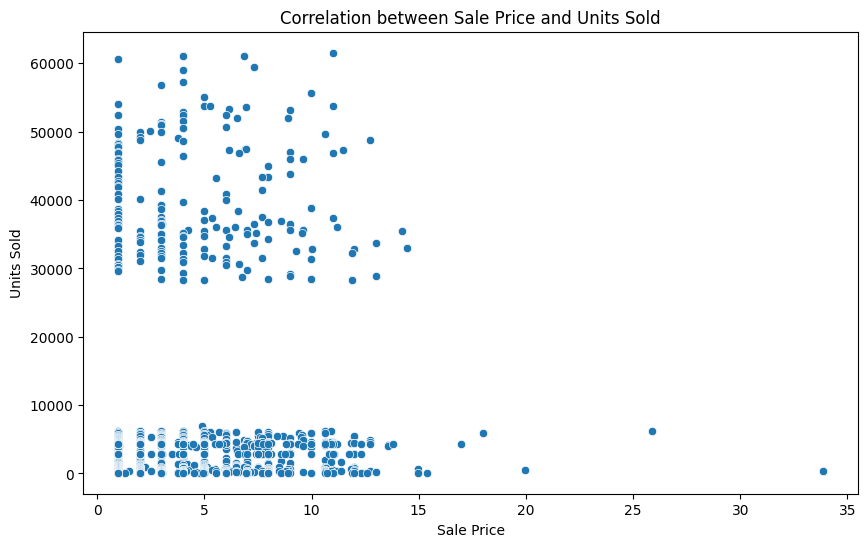

Pearson Correlation Coefficient: -0.0009426307416614935


In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='sale_price', y='units_sold', data=df)
plt.title('Correlation between Sale Price and Units Sold')
plt.xlabel('Sale Price')
plt.ylabel('Units Sold')
plt.show()

# Correlation Coefficient
correlation_coefficient = df['sale_price'].corr(df['units_sold'])
print(f"Pearson Correlation Coefficient: {correlation_coefficient}")

In [32]:
sample = X_test.iloc[[0]]

prediction = rf.predict(sample)

if prediction[0] == 1:
    print("Prediction: High Sales")
else:
    print("Prediction: Low Sales")

Prediction: Low Sales


In [33]:
best = accuracy.sort_values(by="Accuracy", ascending=False)

print(best)

             Algorithm  Accuracy
0        Decision Tree     0.985
1        Random Forest     0.975
3                  SVM     0.720
2  Logistic Regression     0.695
